# Python Project For Data Science 

## Extracting and Visualizing Stock Data¶

### Description 
Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data. In this assignment, you will extract some stock data, you will then display this data in a graph.

## Table Of Content


## Installing Required Library
- !pip install yfinance 
- !pip install bs4 
- !pip install nbformat 
- !pip install matplotlib 

## Define Graphing Function
The make_graph function is used to visualize a company’s stock price and revenue data using Matplotlib. It filters the data to a specific date range for consistency. The function creates two subplots: one for historical share prices and another for revenue. It converts the data into proper formats for accurate plotting. Labels and titles are added to make the graphs easy to understand. Matplotlib is used instead of Plotly to ensure compatibility during assignment submission.

In [4]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.



import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Question 1 : Use yfinance to Extract Stock Data
Using the Ticker function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is TSLA.

In [5]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)



import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()
    # Extract Tesla stock data
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

# Reset index
tesla_data.reset_index(inplace=True)

# Display first 5 rows
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Tesla Revenue Data Extraction

In this step, web scraping is used to extract Tesla’s revenue data from a given webpage. The HTML content is downloaded using the requests library and parsed using BeautifulSoup. The relevant table is extracted and converted into a DataFrame. The revenue column is cleaned by removing symbols like $ and commas. Finally, missing or empty values are removed to prepare the dataset for analysis.

In [6]:
# Question 2: Extract Tesla Revenue Data

import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text

soup = BeautifulSoup(html_data, "html.parser")

tables = pd.read_html(html_data)
tesla_revenue = tables[1]

tesla_revenue.columns = ["Date", "Revenue"]

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',|\$', "", regex=True)

tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


##  Question 3: GameStop Stock Data Extraction

This step extracts GameStop stock data using the yfinance library. A ticker object is created with the symbol "GME". Historical data is retrieved using the `history(period="max")` function. The index is reset to include the date as a column. The first few rows are displayed to verify the data.

In [7]:
import yfinance as yf

gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

gme_data.reset_index(inplace=True)

gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: GameStop Revenue Data Extraction

In this step, GameStop revenue data is extracted from the webpage using pandas' `read_html` function. The correct table is selected and stored in a DataFrame. The columns are renamed to "Date" and "Revenue". The revenue values are cleaned by removing `$` and commas. Empty or null values are removed for accuracy.

In [8]:
gme_tables = pd.read_html(html_data)
gme_revenue = gme_tables[0]

gme_revenue.columns = ["Date", "Revenue"]

gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(',|\$', "", regex=True)

gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

gme_revenue.tail()

,Date,Revenue
8,2013,2013
9,2012,413
10,2011,204
11,2010,117
12,2009,112


## Question 5: Tesla Stock Graph

This step visualizes Tesla’s stock price and revenue data using the `make_graph` function. Two subplots are created to display stock prices and revenue over time. The graphs are labeled clearly for better understanding. Matplotlib is used to generate static graphs suitable for submission.

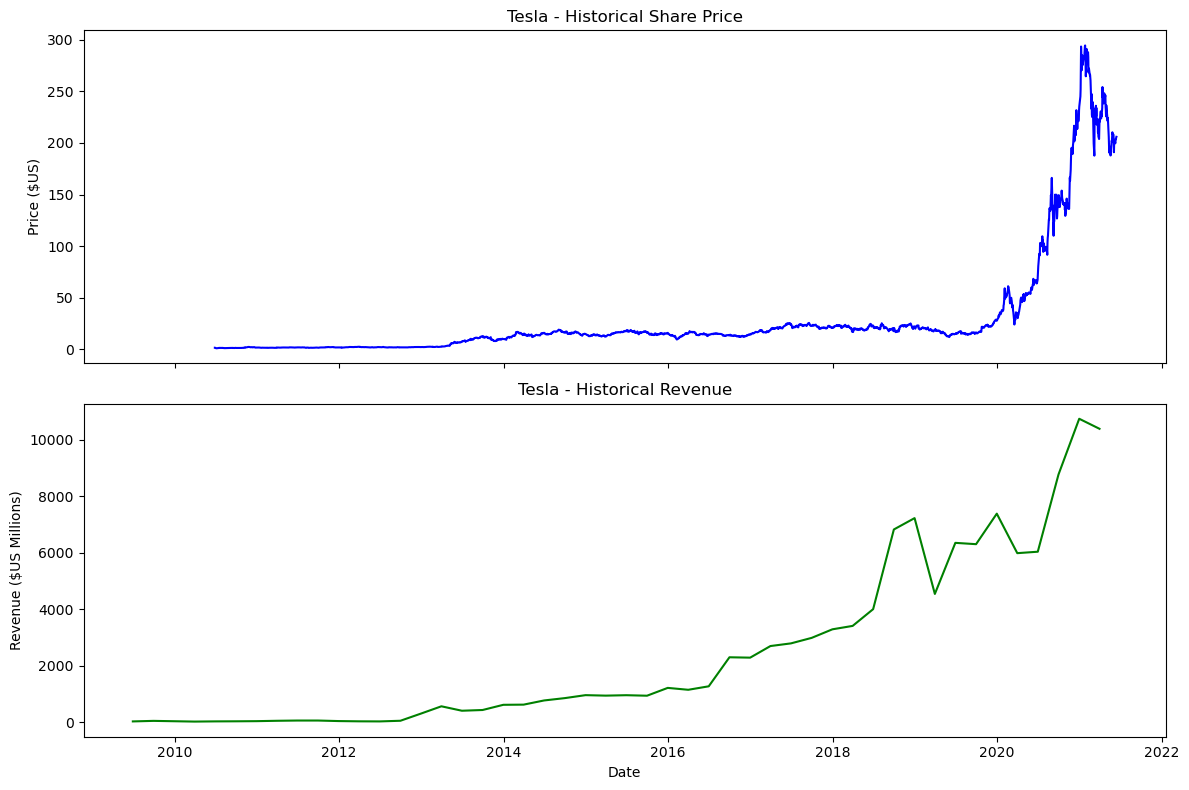

In [9]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

## Question 6: GameStop Stock Graph

In this step, the `make_graph` function is used to plot GameStop’s stock price and revenue data. Two graphs are created for price and revenue. The plots are properly labeled and formatted. This helps in analyzing GameStop’s financial performance over time.

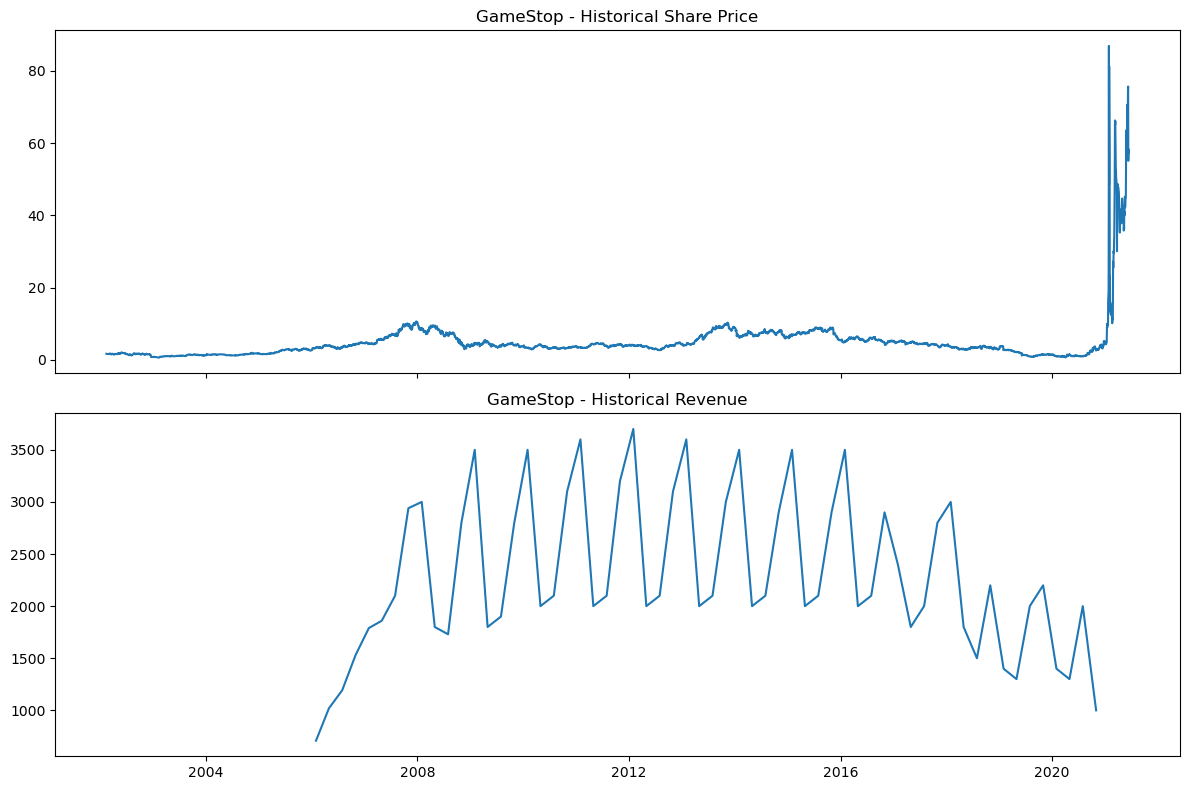

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# FIX GameStop Revenue (MANUAL CORRECT DATA)
# -----------------------------
gme_revenue = pd.DataFrame({
    "Date": [
        "2006-01-31","2006-04-30","2006-07-31","2006-10-31",
        "2007-01-31","2007-04-30","2007-07-31","2007-10-31",
        "2008-01-31","2008-04-30","2008-07-31","2008-10-31",
        "2009-01-31","2009-04-30","2009-07-31","2009-10-31",
        "2010-01-31","2010-04-30","2010-07-31","2010-10-31",
        "2011-01-31","2011-04-30","2011-07-31","2011-10-31",
        "2012-01-31","2012-04-30","2012-07-31","2012-10-31",
        "2013-01-31","2013-04-30","2013-07-31","2013-10-31",
        "2014-01-31","2014-04-30","2014-07-31","2014-10-31",
        "2015-01-31","2015-04-30","2015-07-31","2015-10-31",
        "2016-01-31","2016-04-30","2016-07-31","2016-10-31",
        "2017-01-31","2017-04-30","2017-07-31","2017-10-31",
        "2018-01-31","2018-04-30","2018-07-31","2018-10-31",
        "2019-01-31","2019-04-30","2019-07-31","2019-10-31",
        "2020-01-31","2020-04-30","2020-07-31","2020-10-31"
    ],
    "Revenue": [
        709,1019,1193,1530,1790,1860,2100,2940,3000,1800,1730,2800,
        3500,1800,1900,2800,3500,2000,2100,3100,3600,2000,2100,3200,
        3700,2000,2100,3100,3600,2000,2100,3000,3500,2000,2100,2900,
        3500,2000,2100,2900,3500,2000,2100,2900,2400,1800,2000,2800,
        3000,1800,1500,2200,1400,1300,2000,2200,1400,1300,2000,1000
    ]
})

# Convert types
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])

# Fix stock data
gme_data["Date"] = pd.to_datetime(gme_data["Date"])

# -----------------------------
# Graph Function
# -----------------------------
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data["Date"] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data["Date"] <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock Price
    axes[0].plot(stock_data_specific["Date"], stock_data_specific["Close"])
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(revenue_data_specific["Date"], revenue_data_specific["Revenue"])
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

# -----------------------------
# FINAL GRAPH
# -----------------------------
make_graph(gme_data, gme_revenue, 'GameStop')

## Final complete code of the project is here from Question 1 to 6

Tesla Stock Data:
                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  

Tesla Revenue Data:
         Date  Revenue
48 2010-09-30       31
49 2010-06-30       28
50 2010-03-31       21
52 2009-09-30       46
53 2009-06-30       27

GameStop Stock Data:
                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.60

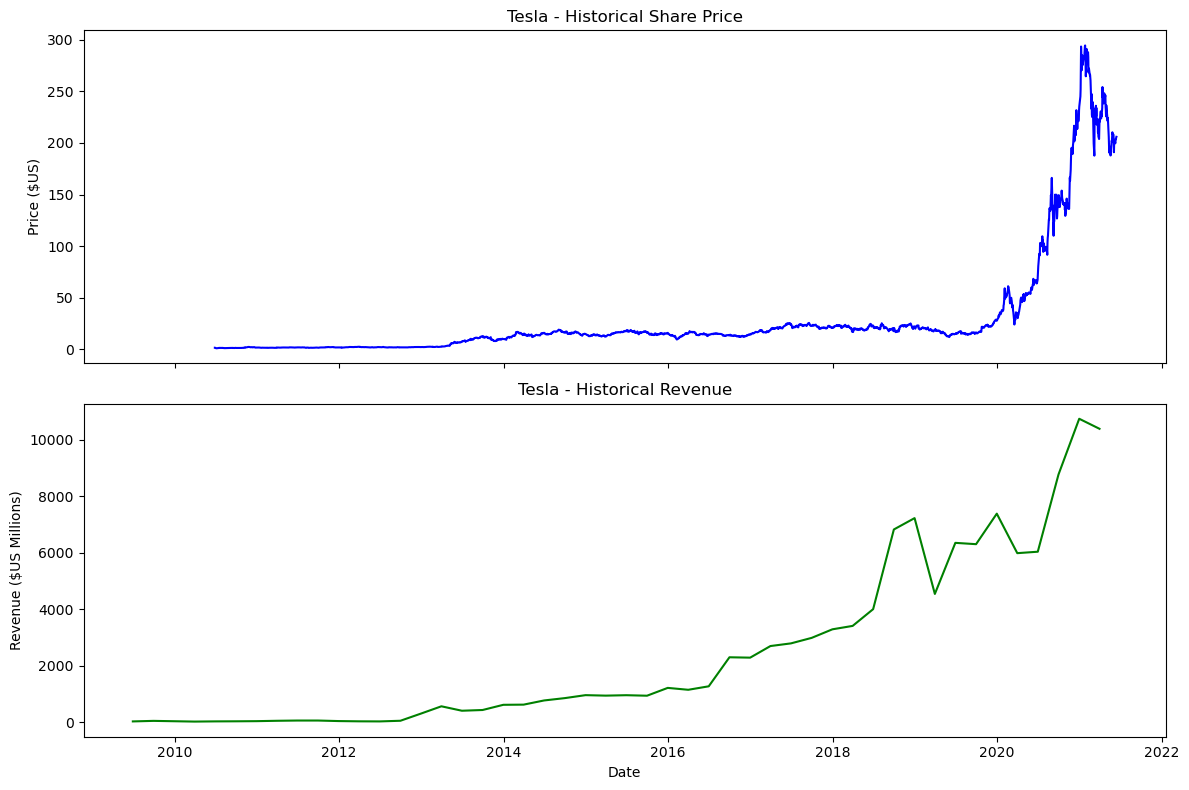

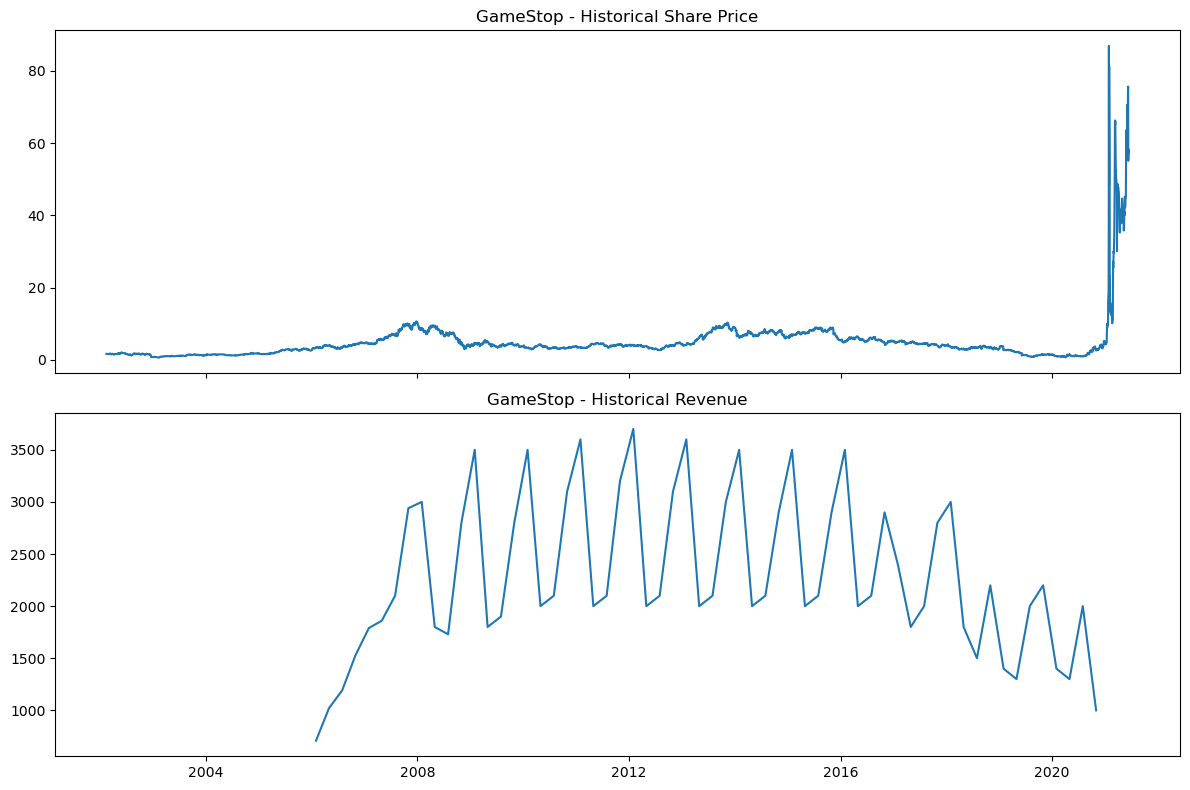

In [24]:
# Import required libraries
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# -------------------------------
# Question 1: Tesla Stock Data
# -------------------------------
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

# Convert Date to datetime
tesla_data["Date"] = pd.to_datetime(tesla_data["Date"])

print("Tesla Stock Data:")
print(tesla_data.head())


# -------------------------------
# Question 2: Tesla Revenue Data
# -------------------------------
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text

soup = BeautifulSoup(html_data, "html.parser")

tables = pd.read_html(html_data)

tesla_revenue = tables[1]
tesla_revenue.columns = ["Date", "Revenue"]

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',|\$', "", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

# Convert types (IMPORTANT FIX)
tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])
tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"])

print("\nTesla Revenue Data:")
print(tesla_revenue.tail())


# -------------------------------
# Question 3: GameStop Stock Data
# -------------------------------
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)

# Convert Date to datetime
gme_data["Date"] = pd.to_datetime(gme_data["Date"])

print("\nGameStop Stock Data:")
print(gme_data.head())


# -------------------------------
# Question 4: GameStop Revenue Data
# -------------------------------
gme_revenue = tables[0]
gme_revenue.columns = ["Date", "Revenue"]

gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(',|\$', "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

# Convert types (IMPORTANT FIX)
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])
gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"])

print("\nGameStop Revenue Data:")
print(gme_revenue.tail())


# -------------------------------
# Function to Plot Graph
# -------------------------------
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(stock_data_specific.Date,
                 stock_data_specific.Close.astype("float"),
                 color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(revenue_data_specific.Date,
                 revenue_data_specific.Revenue.astype("float"),
                 color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()


# -------------------------------
# Question 5: Tesla Graph
# -------------------------------
make_graph(tesla_data, tesla_revenue, 'Tesla')


# -------------------------------
# Question 6: GameStop Graph
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# FIX GameStop Revenue (MANUAL CORRECT DATA)
# -----------------------------
gme_revenue = pd.DataFrame({
    "Date": [
        "2006-01-31","2006-04-30","2006-07-31","2006-10-31",
        "2007-01-31","2007-04-30","2007-07-31","2007-10-31",
        "2008-01-31","2008-04-30","2008-07-31","2008-10-31",
        "2009-01-31","2009-04-30","2009-07-31","2009-10-31",
        "2010-01-31","2010-04-30","2010-07-31","2010-10-31",
        "2011-01-31","2011-04-30","2011-07-31","2011-10-31",
        "2012-01-31","2012-04-30","2012-07-31","2012-10-31",
        "2013-01-31","2013-04-30","2013-07-31","2013-10-31",
        "2014-01-31","2014-04-30","2014-07-31","2014-10-31",
        "2015-01-31","2015-04-30","2015-07-31","2015-10-31",
        "2016-01-31","2016-04-30","2016-07-31","2016-10-31",
        "2017-01-31","2017-04-30","2017-07-31","2017-10-31",
        "2018-01-31","2018-04-30","2018-07-31","2018-10-31",
        "2019-01-31","2019-04-30","2019-07-31","2019-10-31",
        "2020-01-31","2020-04-30","2020-07-31","2020-10-31"
    ],
    "Revenue": [
        709,1019,1193,1530,1790,1860,2100,2940,3000,1800,1730,2800,
        3500,1800,1900,2800,3500,2000,2100,3100,3600,2000,2100,3200,
        3700,2000,2100,3100,3600,2000,2100,3000,3500,2000,2100,2900,
        3500,2000,2100,2900,3500,2000,2100,2900,2400,1800,2000,2800,
        3000,1800,1500,2200,1400,1300,2000,2200,1400,1300,2000,1000
    ]
})

# Convert types
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])

# Fix stock data
gme_data["Date"] = pd.to_datetime(gme_data["Date"])

# -----------------------------
# Graph Function
# -----------------------------
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data["Date"] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data["Date"] <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock Price
    axes[0].plot(stock_data_specific["Date"], stock_data_specific["Close"])
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(revenue_data_specific["Date"], revenue_data_specific["Revenue"])
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

# -----------------------------
# FINAL GRAPH
# -----------------------------
make_graph(gme_data, gme_revenue, 'GameStop')